# 2. Clustering 

Which genetic perturbations show similar effects, if any? Which clustering method(s) best 
capture(s) the underlying biology? 

Clustering of co-culture condition 

In [40]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile

from scipy.stats import hypergeom, false_discovery_control
from scipy import sparse
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

import warnings
warnings.filterwarnings("ignore")

In [41]:
# Variable setup
CONDITION_COL = "perturbation_2"
PERT_COL      = "perturbation"  
COCULTURE     = "Co-culture" 
CONTROL_LABEL = "control" 

MIN_CELLS       = 20                                # exclude perturbations with too few cells to reduce noise         
EFFECT_QUANTILE = 0.25                              # exclude perturbations with weak response 
N_GENES         = 2000                              # number of genes used for the main clustering
N_GENES_LIST    = [500, 1000, 2000, 5000]           # gene-set sizes used for the robustness analysis
N_CLUSTERS      = 8                                 # target number of clusters (after some testing)
LEIDEN_RES_LIST = [0.3, 0.5, 0.8, 1.0, 1.5, 2.0]

RANDOM_STATE = 0

In [42]:
# Load data
rna_path = "./../data/frangieh"
adata = sc.read_h5ad(f'{rna_path}/rna_qc_normalized.h5ad')

In [43]:
print(adata.obs["perturbation_2"].value_counts(), "\n")
print(adata.obs["perturbation"].value_counts().head(10))

perturbation_2
IFNγ          87590
Co-culture    73114
Control       57627
Name: count, dtype: int64 

perturbation
control    57605
ACTA2       1458
B2M         1379
A2M         1331
AEBP1       1302
CD59        1238
CD274       1222
CTSD        1217
IFNGR2      1203
CSPG4       1195
Name: count, dtype: int64


In [44]:
# Keep only co-culture cells
cc = adata[adata.obs[CONDITION_COL] == COCULTURE].copy()
print(f"cells: {cc.n_obs}\ngenes: {cc.n_vars}\nknockouts: {cc.obs[PERT_COL].nunique()}")

cells: 73114
genes: 23712
knockouts: 249


For averaging cells I chose to use mean log-normalized expression over log2 fold change, as it showed more distinct and biologically interpretable clusters with the downstream clustering methods in a trial run. 

```
# Pseudobulk - using log2 fold change
counts = cc.layers["counts"]
counts = counts.tocsr() if sparse.issparse(counts) else np.asarray(counts)
perts  = cc.obs[PERT_COL].astype(str).values
genes  = cc.var_names

# Sum counts within perturbation & calc CPM (w/ normalization)
def pseudobulk_cpm(mask):
    total = np.asarray(counts[mask].sum(axis=0)).ravel()   # Summed counts per gene
    return total / total.sum() * 1e6                       # CPM

ctrl_cpm = pseudobulk_cpm(perts == CONTROL_LABEL)

# Log2FC
log2fc = {}
for p in np.unique(perts):
    if p == CONTROL_LABEL:
        continue
    log2fc[p] = np.log2(pseudobulk_cpm(perts == p) + 1) - np.log2(ctrl_cpm + 1)
delta = pd.DataFrame(log2fc, index=genes).T               # Perturbations x genes
print(f"log2FC table: {delta.shape}")
```

In [45]:
# Averaging cells - using mean of log-normalized single-cell expression
perts = cc.obs[PERT_COL].values

profiles = {}
for p in pd.unique(perts):
    profiles[p] = np.asarray(cc.X[perts == p].mean(axis=0)).ravel()

pseudobulk = pd.DataFrame(profiles, index=cc.var_names).T
print(f"pseudobulk table: {pseudobulk.shape}")

control_profile = pseudobulk.loc[CONTROL_LABEL]
delta = pseudobulk.drop(index=CONTROL_LABEL) - control_profile

pseudobulk table: (249, 23712)


Further filtering had no effect on the stability and interpretability, which is why it is left out in the final pipeline.

In [46]:
# # Optional filtering
# n_cells = pd.Series(perts).value_counts()
# delta = delta.loc[delta.index.intersection(n_cells[n_cells >= MIN_CELLS].index)]
# print(f"after min-cells filter: {delta.shape[0]} knockouts")

# effect = np.sqrt((delta**2).sum(axis=1))                          # L2 norm of the log2fc vector
# delta = delta.loc[effect[effect >= effect.quantile(EFFECT_QUANTILE)].index]
# print(f"after effect filter: {delta.shape[0]} knockouts")

The genes with the highest variance across the perturbations were selected. Note: as we have pseudobulk data, HVG selection (which selects genes based on cell-to-cell variation instead of perturbation-to-perturbation variation) is less suited here.

In [47]:
# Keep the genes that vary most across perturbations (most informative for clustering)
def select_genes(delta, n_genes):
    top = delta.var(axis=0).sort_values(ascending=False).index[:n_genes]
    return delta[top]

data = select_genes(delta, N_GENES)
print(f"clustering table: {data.shape}")

clustering table: (248, 2000)


In [48]:
# Standardize genes and reduce with PCA (denoise before k-means and Leiden)
pert_adata = sc.AnnData(X=data.values.copy(), obs=pd.DataFrame(index=data.index.astype(str)))

sc.pp.scale(pert_adata, max_value=10)

sc.tl.pca(pert_adata, n_comps=30, random_state=RANDOM_STATE)
X_pca = pert_adata.obsm["X_pca"]

## Clustering

For the main clustering, I compare k-means and Leiden (as they were both discussed extensively in the lectures) as well as hierarchical clustering.

### 1. Hierarchical Clustering

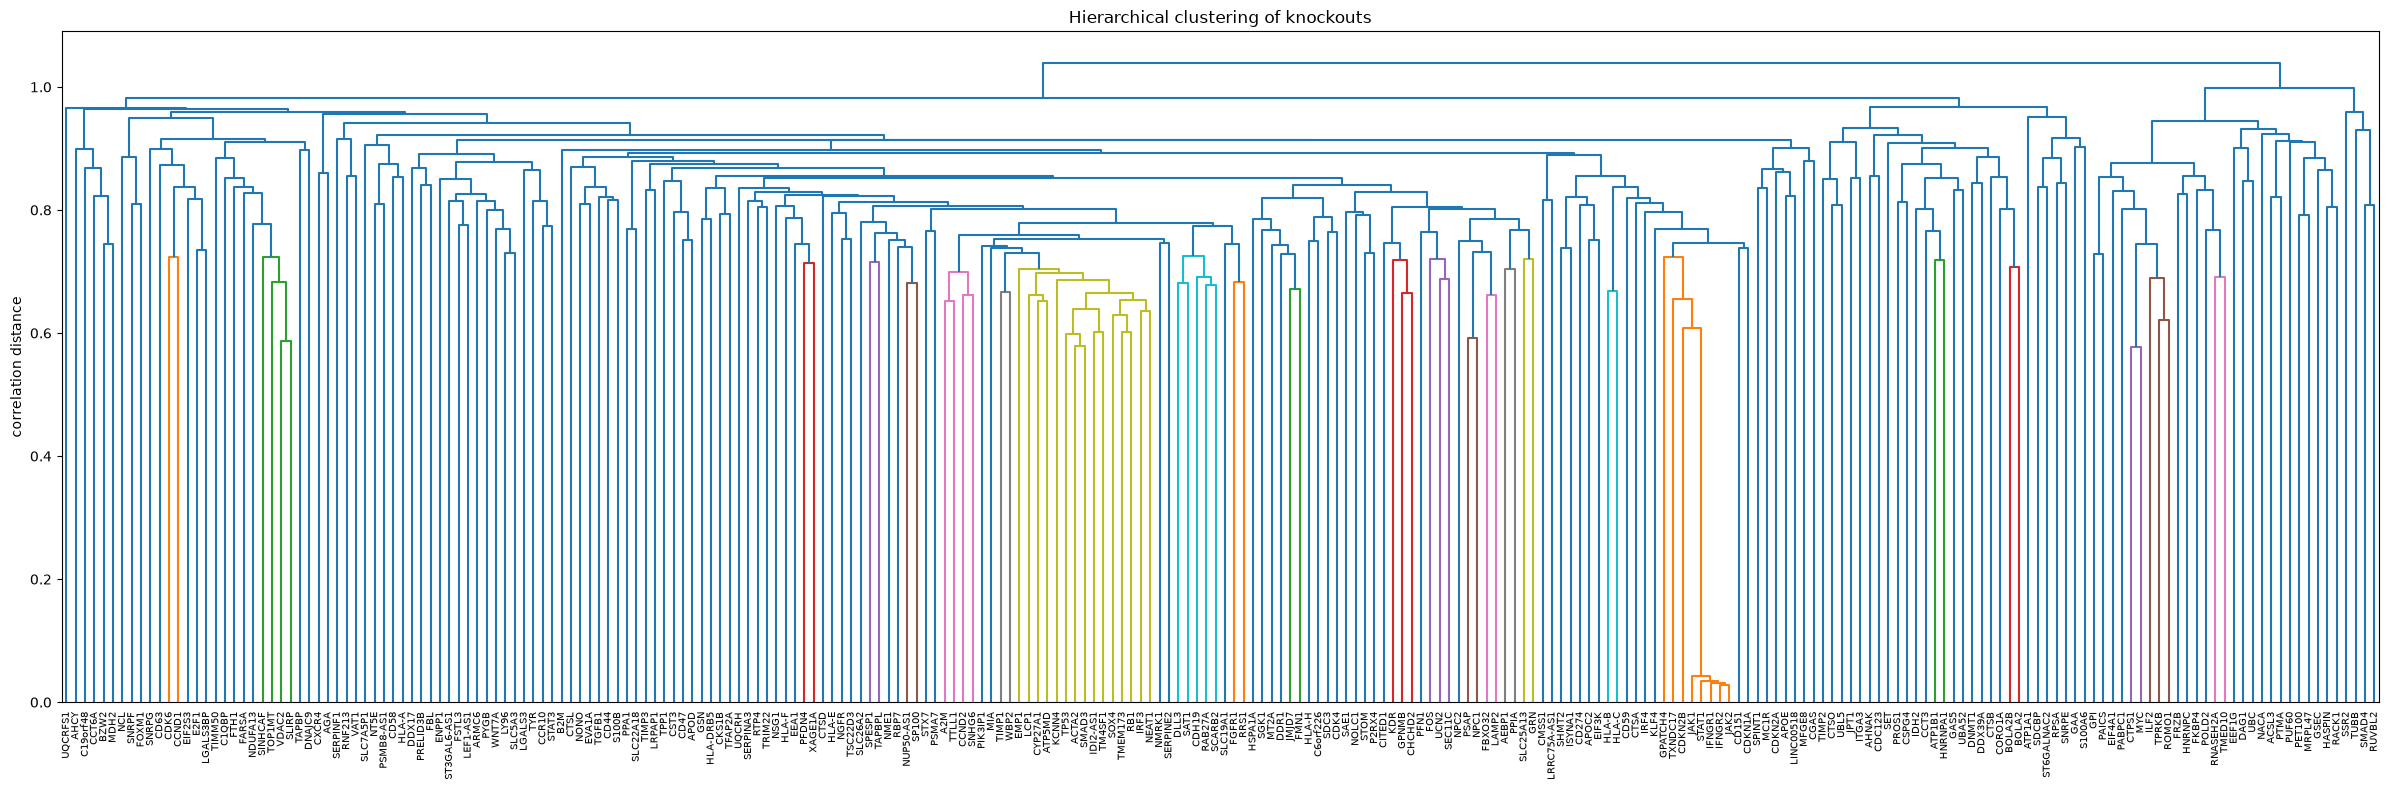

In [49]:
links = linkage(data.values, method="average", metric="correlation")
hier = pd.Series(fcluster(links, N_CLUSTERS, criterion="maxclust"), index=data.index)

plt.figure(figsize=(24, 8))
dendrogram(links, labels=data.index.tolist(), leaf_rotation=90, leaf_font_size=7)
plt.title("Hierarchical clustering of knockouts")
plt.ylabel("correlation distance")
plt.tight_layout()
plt.show()

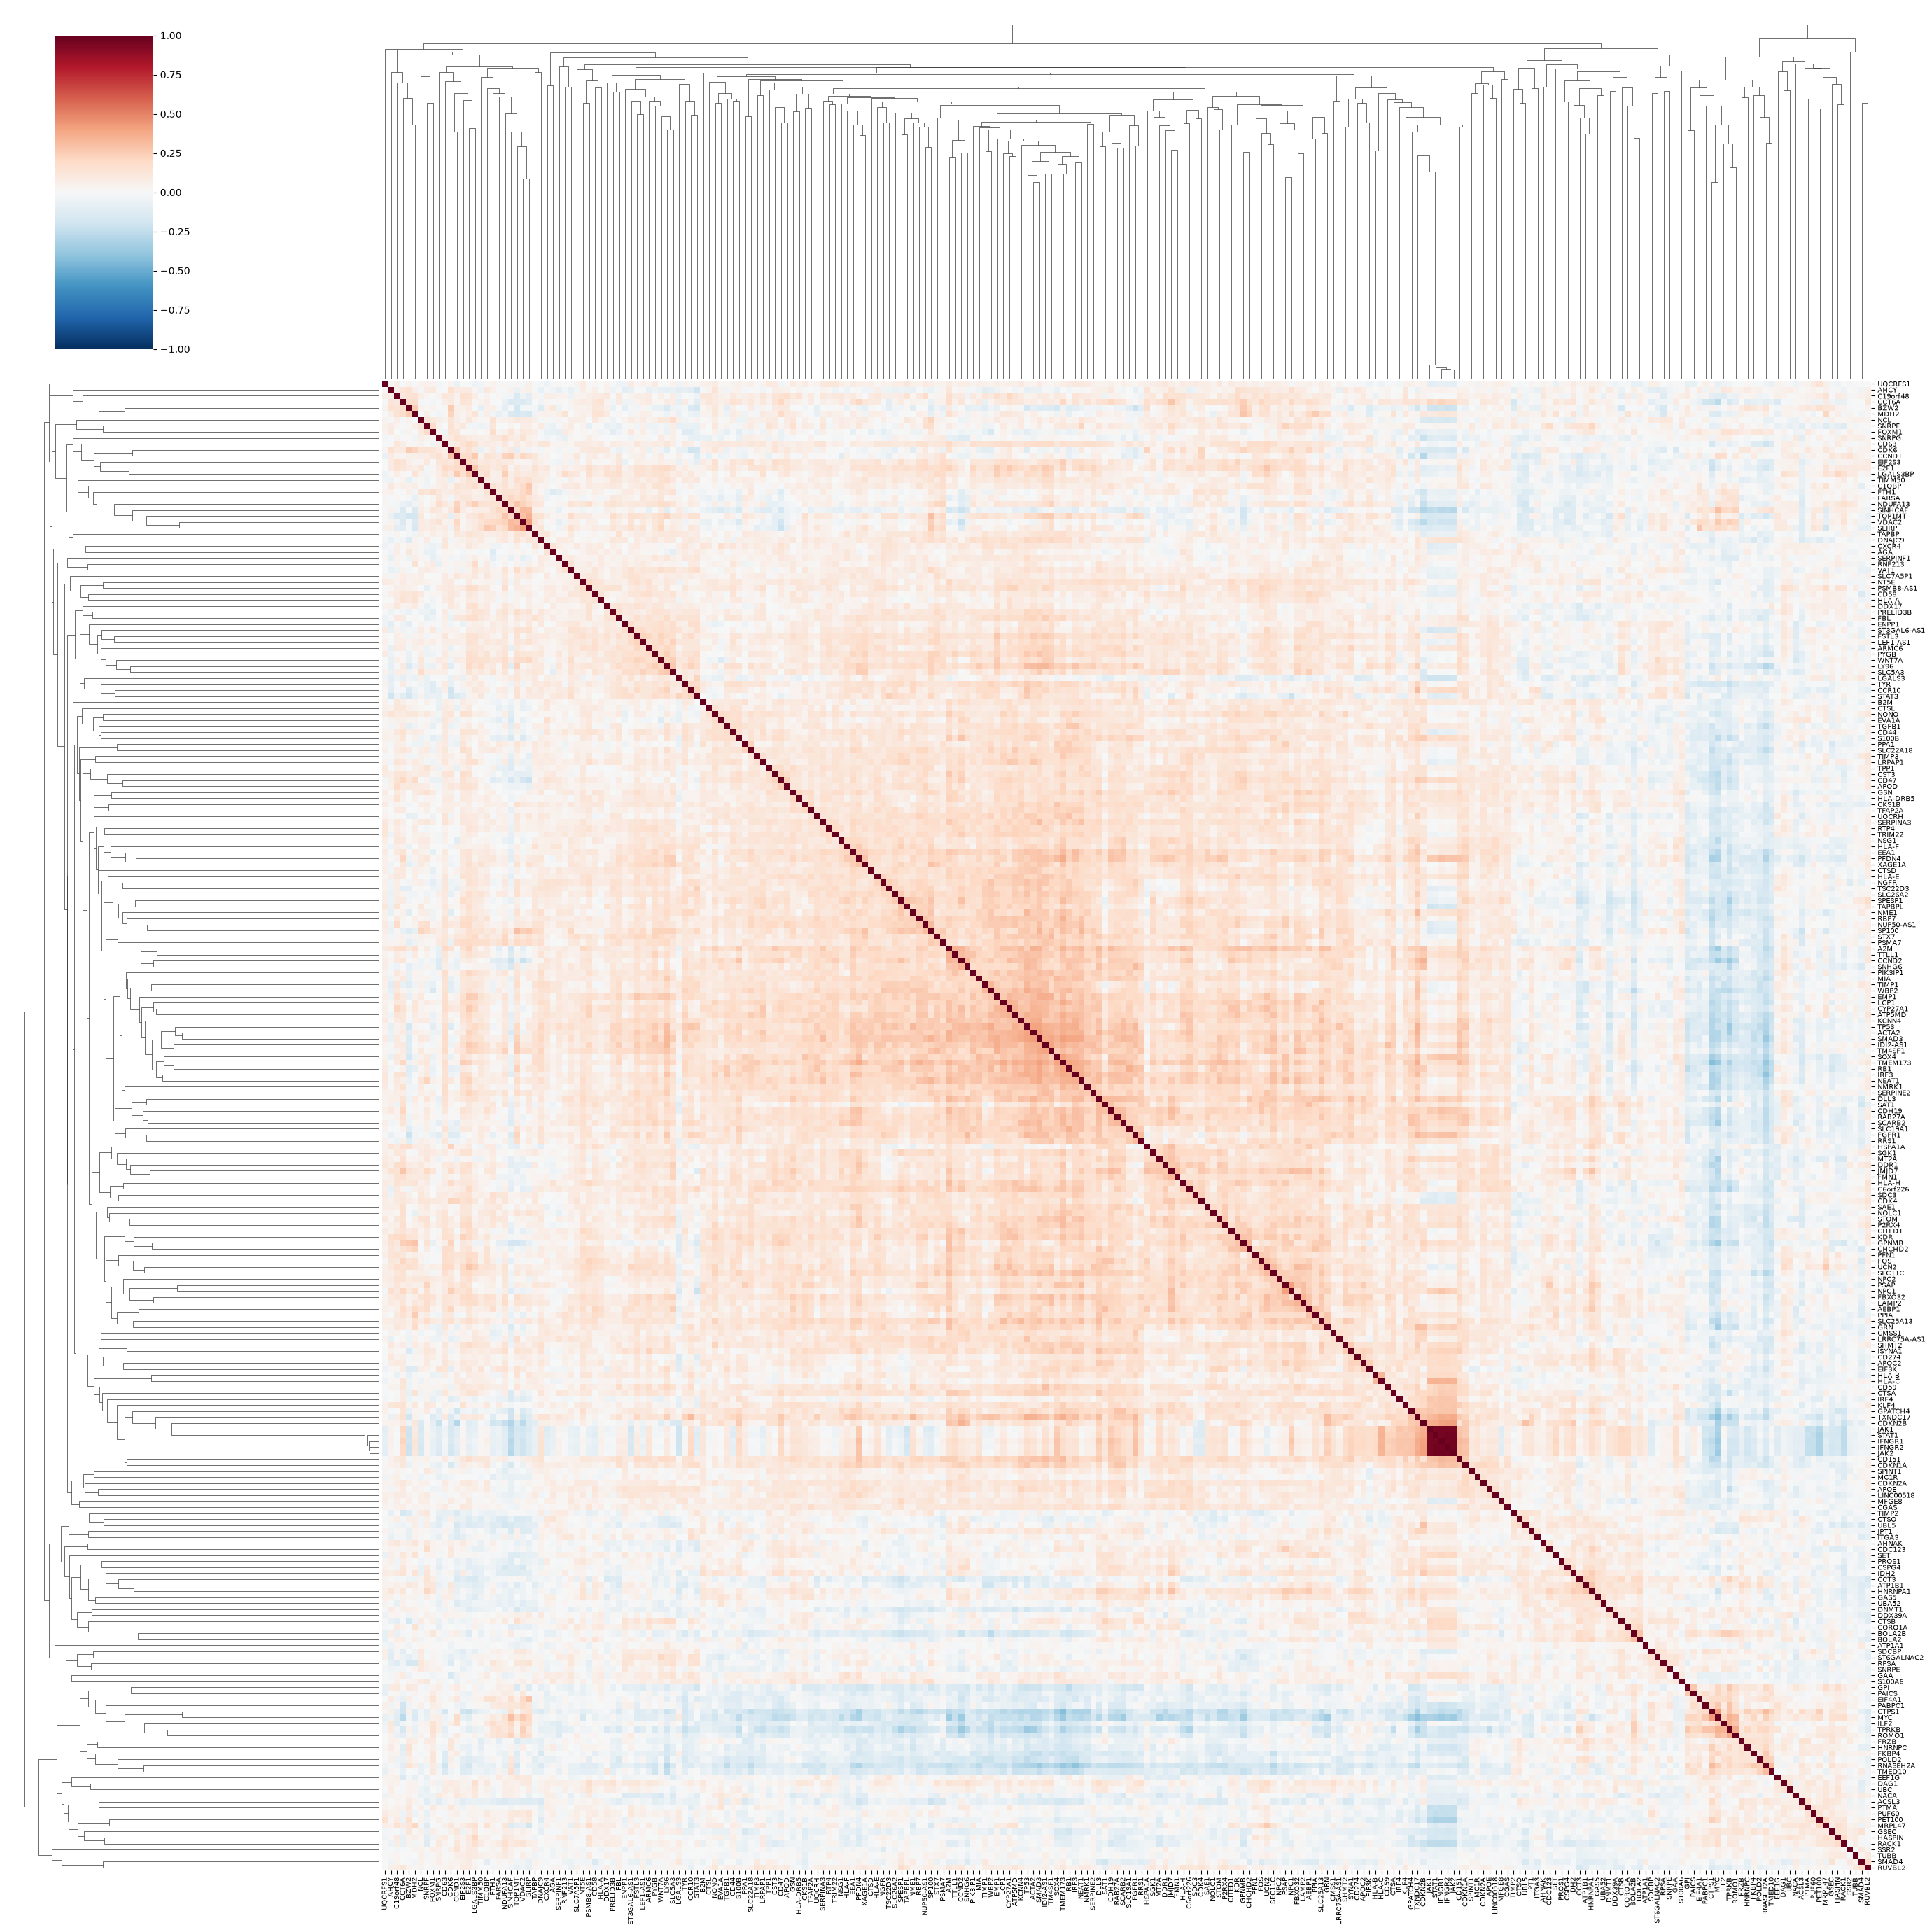

In [50]:
# Correlation between every pair of knockouts, ordered by the clustering
corr = data.T.corr()             # Knockouts x knockouts (Pearson)
g = sns.clustermap(
    corr, 
    row_linkage=links, 
    col_linkage=links,
    cmap="RdBu_r", 
    center=0, 
    vmin=-1, 
    vmax=1,
    figsize=(28, 28), 
    xticklabels=True, 
    yticklabels=True
)

plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=7)
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=7)

# Adjust colorbar position
g.cax.set_position([
    0.03,   # Left
    0.82,   # Bottom
    0.05,   # Width
    0.16    # Height
])

plt.show()

### 2. k-means Clustering

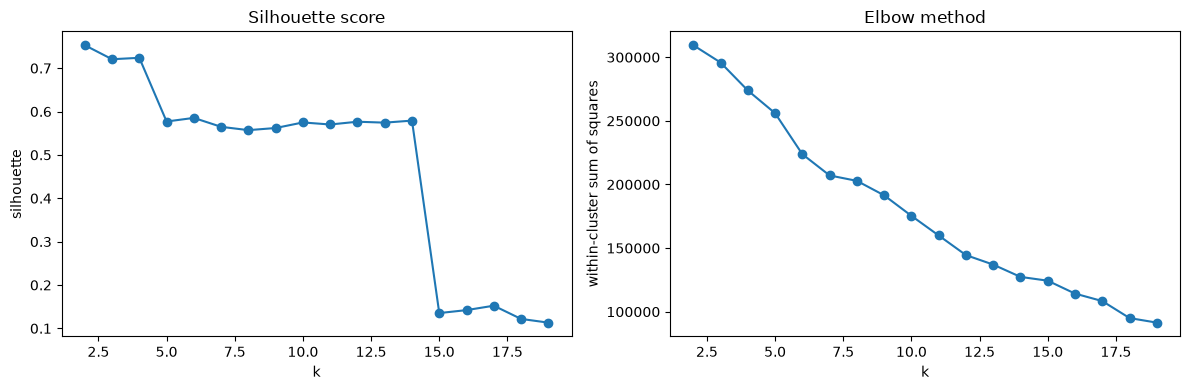

k=2: [247   1]
k=3: [246   1   1]
k=4: [245   1   1   1]
k=5: [ 17   1   1   1 228]
k=6: [ 17   1   1   1 227   1]
k=7: [ 17   1   1   1 222   1   5]
k=8: [237   1   1   1   1   1   1   5]
k=9: [236   1   1   1   1   1   1   5   1]
k=10: [ 18   1   1   1   1   1   1   5   1 218]
k=11: [ 18   1   1   1   1   1   1   5   1 217   1]
k=12: [ 18   1   1   1   1   1   1   5   1 216   1   1]
k=13: [ 17   1   1   1   1   1   1   5   1 216   1   1   1]
k=14: [ 17   1   1   1   1   1   1   5   1 215   1   1   1   1]
k=15: [ 66   1   1   1   1   1   1   5   1 149   1   1   1   1  17]
k=16: [ 68   1   1   1   1   1   1   5   1 149   1   1   1   1  14   1]
k=17: [ 65   1   1   1   1   1   1   5   1 151   1   1   1   1  14   1   1]
k=18: [ 74   1   1   1   1   1   1   5   1 141   1   1   1   1  14   1   1   1]
k=19: [ 63   1   1   1   1   1   1   5   1 133   1   1   1   1  27   1   1   1
   6]


In [51]:
# X_kmeans = X_pca[:, :10]      # doesn't help

ks = range(2, 20)
scores, inertias, labels = [], [], {}

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE).fit(X_pca)
    labels[k] = km.labels_
    scores.append(silhouette_score(X_pca, km.labels_))
    inertias.append(km.inertia_)

# Silhouette + elbow
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(ks, scores, marker="o")
ax[0].set(xlabel="k", ylabel="silhouette", title="Silhouette score")

ax[1].plot(ks, inertias, marker="o")
ax[1].set(xlabel="k", ylabel="within-cluster sum of squares", title="Elbow method")

plt.tight_layout()
plt.show()

# Cluster sizes for each k
for k in ks:
    print(f"k={k}: {np.bincount(labels[k])}")

For all k's the custers look extremely imbalanced, meaning either the my the way I'm representing my data (as averaged expressions) isn't good or something went wrong with my processing at some point, which I am currently overlooking. I tried out different approaches to solve the problem, such as using PCs for only standardized scores for the clustering or varying the number of PC used, but it doesn't seem to make a difference. Therefore, I will now continue with k=10 as the silhouette score seems halfway decent and it is the first point where the cluster splits into one main and one (decently sized) subcluster. The k-means clusters should however be treated very sceptically.

In [52]:
kmeans = KMeans(n_clusters=10, random_state=RANDOM_STATE).fit_predict(X_pca)
kmeans = pd.Series(kmeans, index=data.index)

### 3. Leiden Clustering

Do Leiden clustering with different resolutions and compare to hierarchical clustering using Adjusted Rand Index (ARI).

Resolution: number of clusters (ARI vs hierarchical)
	0.3: 1 clusters (ARI 0.00)
	0.5: 4 clusters (ARI -0.04)
	0.8: 7 clusters (ARI 0.04)
	1.0: 8 clusters (ARI 0.07)
	1.5: 11 clusters (ARI 0.05)
	2.0: 15 clusters (ARI 0.05)


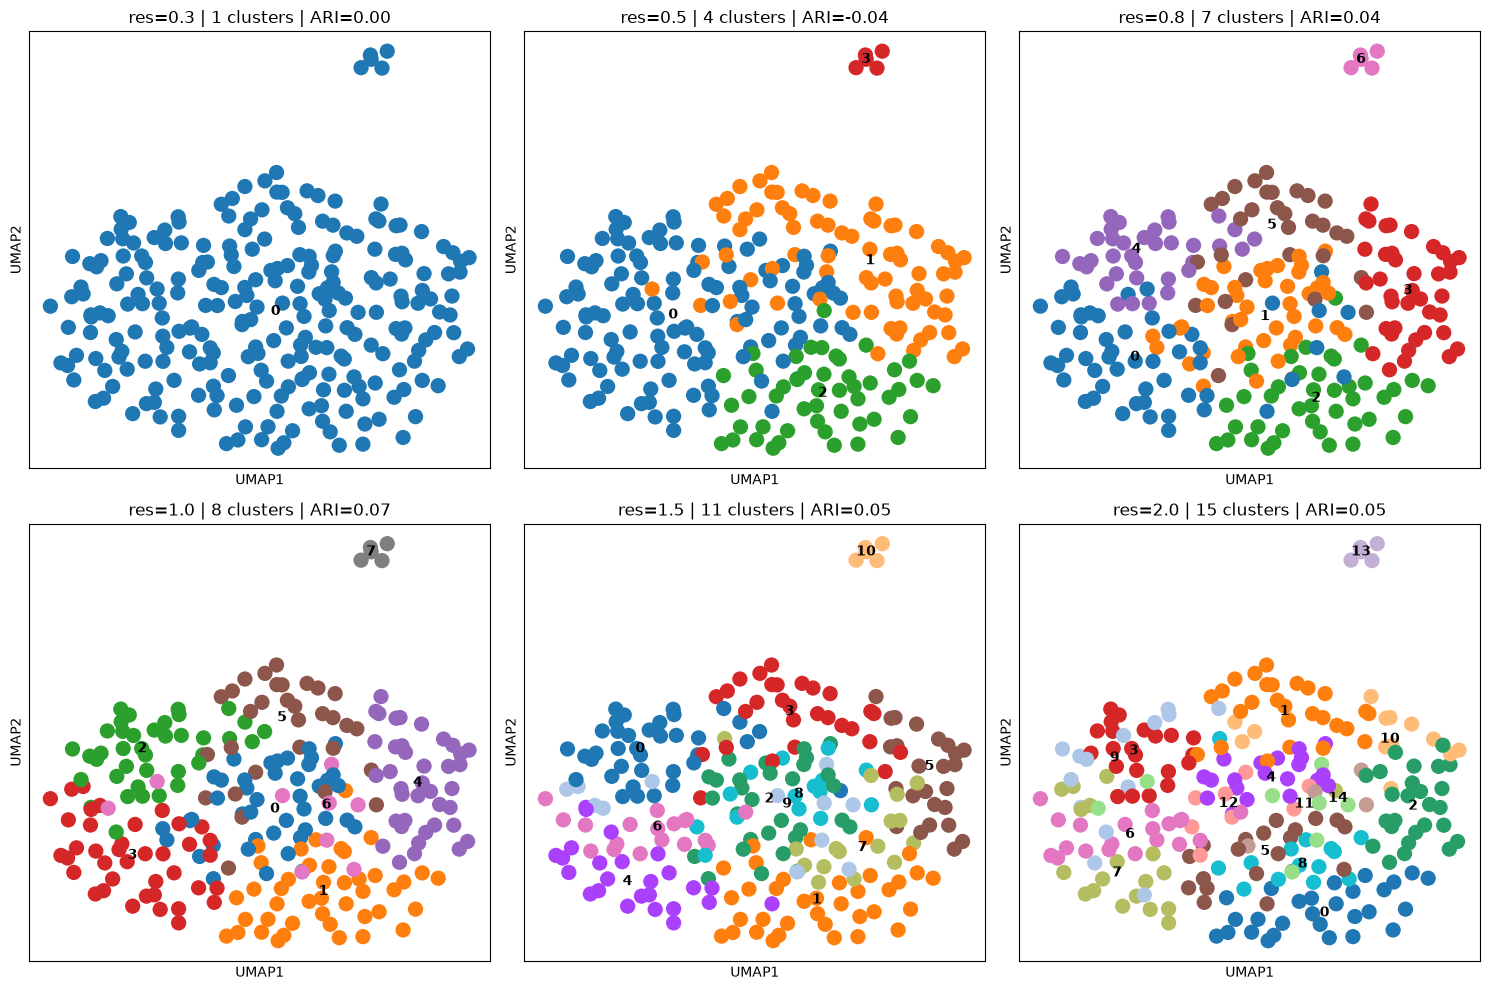

In [53]:
sc.pp.neighbors(pert_adata, use_rep="X_pca")

print("Resolution: number of clusters (ARI vs hierarchical)")

sc.tl.umap(pert_adata, random_state=RANDOM_STATE)

n_cols = (len(LEIDEN_RES_LIST) + 1) // 2
fig, axes = plt.subplots(
    2, n_cols,
    figsize=(5 * len(LEIDEN_RES_LIST)/2, 10)
)
axes = axes.flatten()

for ax, res in zip(axes, LEIDEN_RES_LIST):

    key = f"leiden_{res}"

    sc.tl.leiden(
        pert_adata,
        resolution=res,
        key_added=key,
        random_state=RANDOM_STATE
    )

    labels = pert_adata.obs[key].astype(int).values
    n = pert_adata.obs[key].nunique()

    ari = adjusted_rand_score(
        hier.loc[data.index].values,
        labels
    )

    print(f"\t{res}: {n} clusters (ARI {ari:.2f})")

    sc.pl.umap(
        pert_adata,
        color=key,
        title=f"res={res} | {n} clusters | ARI={ari:.2f}",
        legend_loc="on data",
        ax=ax,
        show=False
    )

plt.tight_layout()
plt.show()

In [54]:
# Choose best resolution
counts_by_res = {r: pert_adata.obs[f"leiden_{r}"].nunique() for r in LEIDEN_RES_LIST}
best_res = min(counts_by_res, key=lambda r: abs(counts_by_res[r] - N_CLUSTERS))
print("chosen resolution:", best_res)

leiden = pert_adata.obs[f"leiden_{best_res}"].astype(int)
leiden.index = data.index
print(leiden.value_counts().sort_index())

chosen resolution: 1.0
leiden_1.0
0    43
1    43
2    39
3    39
4    39
5    31
6     9
7     5
Name: count, dtype: int64


### Method Comparison

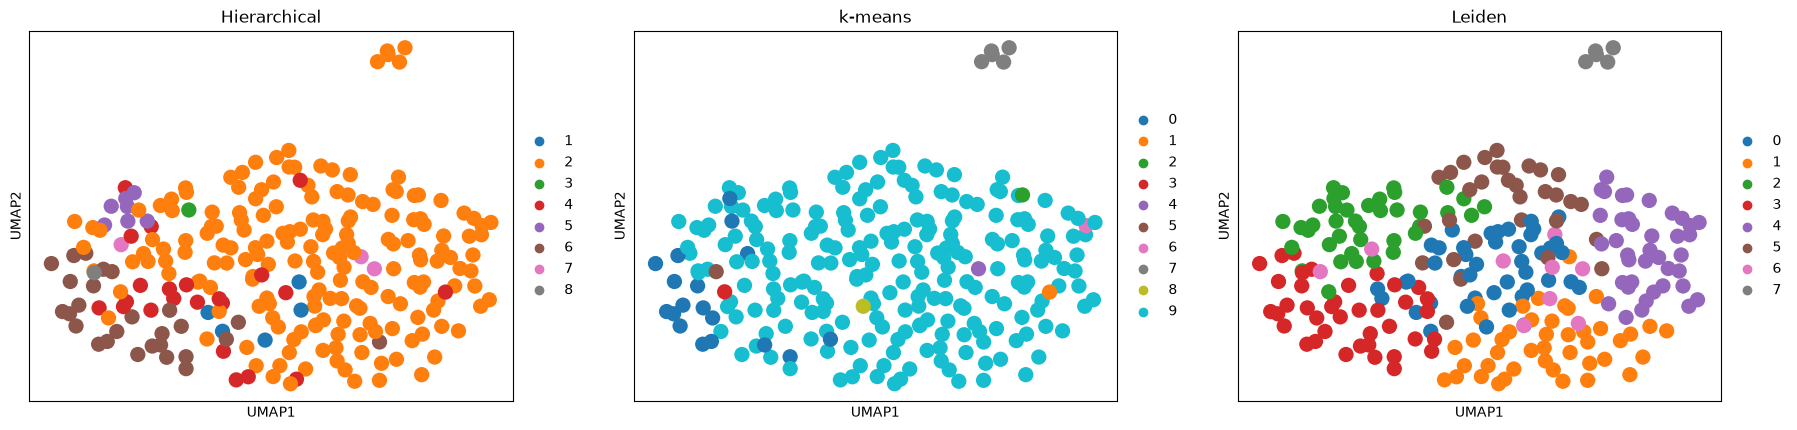

In [55]:
# Visualize the three clusterings on one UMAP embedding of the perturbations
pert_adata.obs["hierarchical"] = pd.Categorical(hier.loc[data.index].astype(str).values)
pert_adata.obs["k-means"]      = pd.Categorical(kmeans.loc[data.index].astype(str).values)
pert_adata.obs["leiden"]       = pd.Categorical(leiden.loc[data.index].astype(str).values)
sc.pl.umap(pert_adata, color=["hierarchical", "k-means", "leiden"], ncols=3, title=["Hierarchical", "k-means", "Leiden"])

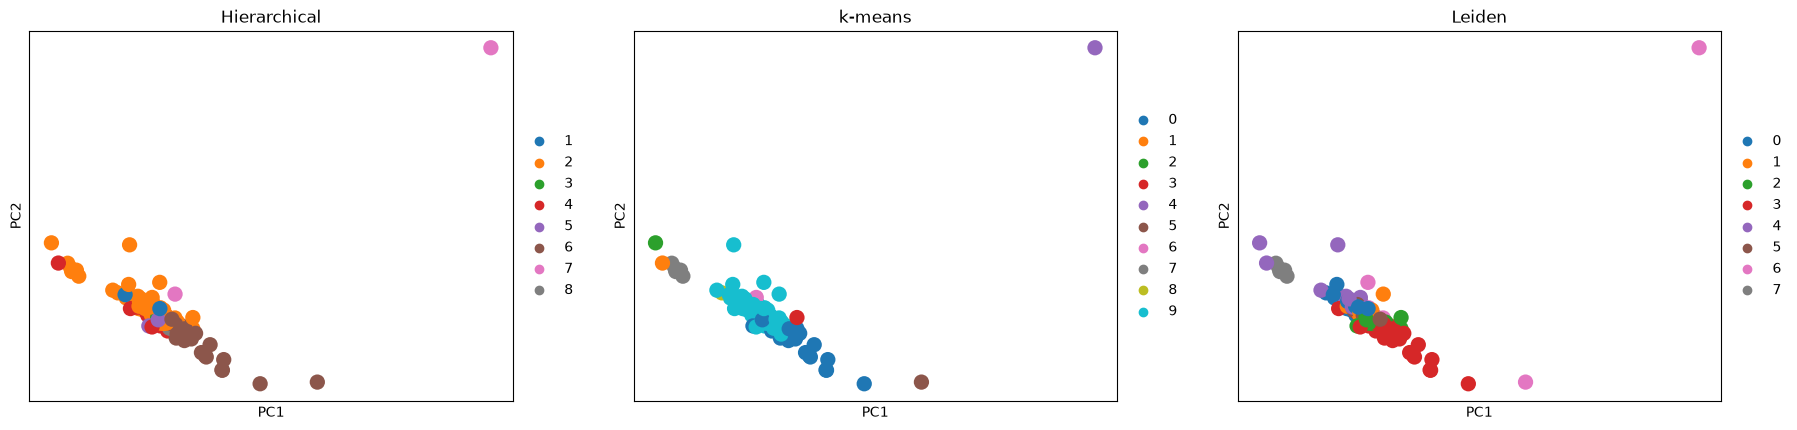

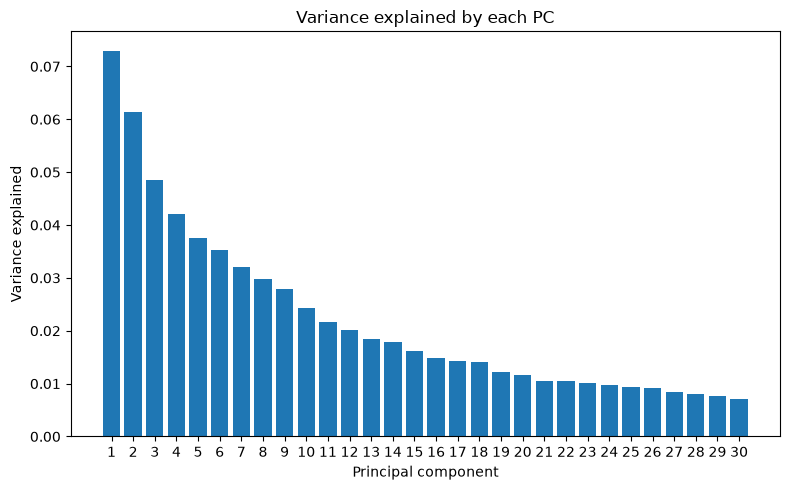

In [56]:
# PCA
sc.pl.pca(
    pert_adata,
    color=["hierarchical", "k-means", "leiden"],
    ncols=3,
    title=["Hierarchical", "k-means", "Leiden"]
)

# Inspect PCs
variance = pert_adata.uns["pca"]["variance_ratio"]

plt.figure(figsize=(8, 5))
plt.bar(
    range(1, len(variance) + 1),
    variance
)

plt.xlabel("Principal component")
plt.ylabel("Variance explained")
plt.title("Variance explained by each PC")
plt.xticks(range(1, len(variance) + 1))
plt.tight_layout()
plt.show()

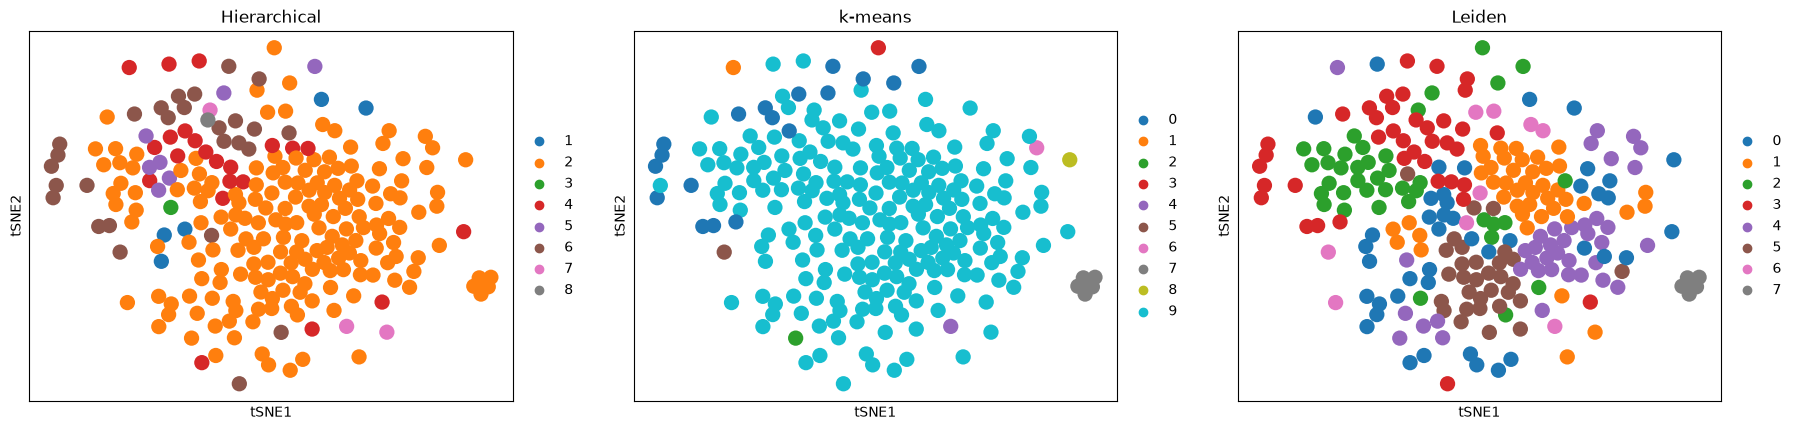

In [57]:
# t-SNE
sc.tl.tsne(
    pert_adata, 
    n_pcs=30, 
    random_state=RANDOM_STATE
)

sc.pl.tsne(
    pert_adata,
    color=["hierarchical", "k-means", "leiden"],
    ncols=3,
    title=["Hierarchical", "k-means", "Leiden"]
)

In [58]:
print(f"{str('hierarchical vs k-means'):18s}: {round(adjusted_rand_score(hier, kmeans), 2)}")
print(f"{str('hierarchical vs leiden'):18s}: {round(adjusted_rand_score(hier, leiden), 2)}")
print(f"{str('k-means vs leiden'):18s}: {round(adjusted_rand_score(kmeans, leiden), 2)}")

hierarchical vs k-means: 0.23
hierarchical vs leiden: 0.07
k-means vs leiden : 0.03


In [59]:
def cluster_all(delta, n_genes, n_clusters=N_CLUSTERS):
    d = select_genes(delta, n_genes)

    # Hierarchical (correlation distance)
    L = linkage(d.values, method="average", metric="correlation")
    h = pd.Series(fcluster(L, n_clusters, criterion="maxclust"), index=d.index)

    # K-means and Leiden on standardized data reduced with PCA
    scl = StandardScaler().fit_transform(d.values)
    a = sc.AnnData(scl, obs=pd.DataFrame(index=d.index.astype(str)))
    sc.pp.pca(a, n_comps=min(30, scl.shape[0] - 1, scl.shape[1] - 1), random_state=RANDOM_STATE)

    k = pd.Series(KMeans(n_clusters, random_state=RANDOM_STATE).fit_predict(a.obsm["X_pca"]), index=d.index)

    sc.pp.neighbors(a, use_rep="X_pca")
    sc.tl.leiden(a, resolution=best_res, random_state=RANDOM_STATE)
    le = pd.Series(a.obs["leiden"].astype(int).values, index=d.index)

    return {"hierarchical": h, "k-means": k, "leiden": le}

ref = cluster_all(delta, N_GENES)
rows = []
for n in N_GENES_LIST:
    lab = cluster_all(delta, n)
    rows.append({"N_GENES": n, **{m: round(adjusted_rand_score(ref[m], lab[m]), 2) for m in ref}})
print("ARI vs the N_GENES = 2000 clustering:")
print(pd.DataFrame(rows).to_string(index=False))

ARI vs the N_GENES = 2000 clustering:
 N_GENES  hierarchical  k-means  leiden
     500          0.70     0.31    0.31
    1000          0.65     0.39    0.44
    2000          1.00     1.00    1.00
    5000          0.68     0.23    0.33


In [60]:
# Cluster compositions (up- and down-regulated genes)
def cluster_comp(cluster, name):
    for c in sorted(cluster.unique()):
        members = hier.index[cluster == c].tolist()
        avg = delta.loc[members].mean().sort_values()
        print(f"\n{name} Cluster {c}  ({len(members)} knockouts)")
        print("  knockouts:", ", ".join(members[:25]))
        print("  genes up  :", ", ".join(avg.tail(10).index[::-1]))
        print("  genes down:", ", ".join(avg.head(10).index))

cluster_comp(hier, "Hierarchical")
cluster_comp(leiden, "Leiden")


Hierarchical Cluster 1  (5 knockouts)
  knockouts: C19orf48, BZW2, MDH2, CCT6A, AHCY
  genes up  : KRT8, PTGES, MT-ND4, HIST1H4C, FN1, ATP5MC1, LY6E, CCT2, BASP1, QPRT
  genes down: EREG, SLC20A1, MDH2, TMEM158, SH3BGRL3, SRGN, AP1S1, CCT6A, BRI3, S100A10

Hierarchical Cluster 2  (182 knockouts)
  knockouts: SLC26A2, CCND2, CD44, CDKN2A, JMJD7, CTSD, CTSL, SERPINA3, B2M, ST3GAL6-AS1, SPINT1, TMEM173, JAK1, DLL3, HLA-E, KCNN4, TIMP1, IFNGR2, TYR, CD151, FSTL3, LGALS3, NT5E, CITED1, CYP27A1
  genes up  : PTGR1, NPM1, HSPD1, COA6, ZFAS1, FTL, CAV1, TXNRD1, RPL13A, RPL23
  genes down: MT2A, TIMP1, IL1B, S100A13, MSMP, SFRP1, PKIB, HLA-DRA, HLA-DPB1, DUSP6

Hierarchical Cluster 3  (1 knockouts)
  knockouts: UQCRFS1
  genes up  : HLA-DRA, HLA-DRB1, RPS20, WDR74, MRPL33, HLA-DPA1, NNMT, ID1, SDF4, PHLDA1
  genes down: UQCRFS1, ATP6V1D, WDR1, RPLP0, DDOST, PTPRN2, RAB32, KRT10, DCBLD2, RAB14

Hierarchical Cluster 4  (22 knockouts)
  knockouts: DNMT1, CTSB, CTSO, BOLA2B, PROS1, DDX39A, AHNAK, 

In [61]:
# GO enrichments for top genes of the clusters
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)

def go_clusters(clusters, name):
    for c in sorted(clusters.unique()):
        members = clusters.index[clusters == c]
        if len(members) < 3:
            continue

        avg = delta.loc[members].mean().sort_values()
        genes = list(avg.tail(15).index) + list(avg.head(15).index)

        res = gp.profile(
            organism="hsapiens",
            query=genes,
            sources=["GO:BP"],
            background=adata.var_names.tolist()
        )

        print(f"\n{name} cluster {c} (n={len(members)})")

        if len(res):
            print(res.sort_values("intersection_size", ascending=False).head(10)[["name", "intersection_size", "p_value"]].to_string(index=False))
        else:
            print("none")

go_clusters(hier, "Hierarchical")
go_clusters(leiden, "Leiden")


Hierarchical cluster 1 (n=5)
none

Hierarchical cluster 2 (n=182)
                                               name  intersection_size  p_value
                      cell population proliferation                 14 0.008829
   negative regulation of protein metabolic process                  9 0.006744
                regulation of lymphocyte activation                  8 0.029734
               positive regulation of cell adhesion                  8 0.025600
negative regulation of protein modification process                  7 0.004104
          negative regulation of molecular function                  7 0.044002
       positive regulation of lymphocyte activation                  7 0.029488
positive regulation of leukocyte cell-cell adhesion                  7 0.008716
           positive regulation of T cell activation                  7 0.005328
          positive regulation of cell-cell adhesion                  7 0.025277

Hierarchical cluster 4 (n=22)
                      

### Discussion [Co-Culture Only]

**General Idea** \
Pseudobulk (mean normalized expression) &rarr; Select variable genes &rarr; Standardize genes &rarr; PCA &rarr; Clustering (hierarchical vs k-means vs Leiden) &rarr; Analysis &rarr; GO enrichment &rarr; Biological interpretation

The idea for the clustering was to first average the perturbations into one row for each perturbation (mean normalized expression) and filter out ambiguous data that negatively affects the clustering. For the clustering itself, the plan was to use three different clustering algorithms (hierarchical, k-means and Leiden clustering) and compare their results with each other as well as the findings from the paper.

**Best Clustering Methods**

When comparing the different clustering methods we can see that they vary widely in their performance. While Leiden clustering was able to find a number of evenly sized clusters, the hierarchical clusters were less balanced, with one big and a few medium to small clusters. The k-means clustering took this even further and had only one very big cluster and a single small one that only appeared for k>=10. It assumes clusters that are roughly spherical and of comparable size, whereas our data is strongly imbalanced (one dominant program over a background of weakly responding perturbations along a single main axis, which is also visible in the PCA variance plot). When comparing the clustering methods using the adjusted rand score (ARI), a similarity measure between two clusterings, we can also see that the clusters are very different from each other and have overall very few samples which are assigned to the same clusters.

**Cluster Analysis**

When looking at the composition of the Leiden and hierarchical clusters themselves, we see that the Leiden clusters agree well with the mechanisms and pathways stated in the paper. The most prominent is hereby cluster 7, containing knockouts of many of the central IFN-$\gamma$/JAK-STAT pathway members, such as JAK1, IFNGR2 and STAT1. These knockouts on the other hand downregulate many of the MHC genes including CD74, HLA-A/B/C, HLA-DRA/DRB1/DPA1, B2M and WARS, which we could already see as prominent features for the classifier in task 1. The additional GO enrichment further supports this by containing many immune response related terms. \
The next interesting Leiden cluster is cluster 2, as it contains CD58 as well as HLA-A and HLA-C. The paper mentioned that CD58 KO was found to confer immune evasion in a mechanism acting orthogonally to IFN-$\gamma$. The fact that it is in the same cluster as HLA-A and HLA-C, whose KO leads to immune evasion as they both encode MHCs, is nicely showing this exact finding. Interestingly, the GO enrichment of this cluster didn't find any significant terms, also displaying the fact that CD58 acts orthogonally to IFN-$\gamma$ instead of directly affecting MHC levels through a clear transcriptional program.\
Other than this we can see further Leiden clusters containing proliferation/cell-cycle (cluster 4 and 5) and stress/apoptosis genes (cluster 3).

Compared to these results, the clusters of the hierarchical do not really show any clear processes like this, having just one very big cluster, containing 182 perturbations affecting a very broad range of processes as can be seen by its gene enrichment. The other few smaller clusters also don't show any of the main processes described above. They do, however, show mitochondrial/oxidative phosphorylation (cluster 4), cell and nuclear division (cluster 5) and response to cytokines (cluster 6).

Overall, looking at the results, I can be said that the Leiden cluster does indeed show some interesting biology, while the other two methods didn't work very well. However, I think with more time and an improved pipeline, the results for this task can definitely be improved upon.